# AI-Assisted Financial Analysis & Anomaly Detection

This notebook demonstrates how Python and AI-assisted reasoning can support financial data review in a simulated corporate expense-management scenario.

**Important:** All data used in this project are synthetic. The analysis is designed for portfolio demonstration only and does not represent a real company, client, employee or audit engagement.

## Objectives

The analysis focuses on six review areas:

1. High-value transactions
2. Duplicate-like transactions
3. Weekend transactions
4. High-frequency reimbursements
5. Vendor concentration
6. Department-level spending spikes

AI is used as an analytical assistant for structuring the workflow, code support and interpretation. Final risk criteria and conclusions require human validation and business context.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")


## 1. Load and inspect the synthetic expense dataset

In [2]:
# Works both in the GitHub project structure and when the Excel file is placed beside the notebook.
possible_paths = [
    Path("../data/synthetic_expense_data.xlsx"),
    Path("data/synthetic_expense_data.xlsx"),
    Path("synthetic_expense_data.xlsx"),
    Path("/mnt/data/synthetic_expense_data.xlsx")
]

data_path = next((p for p in possible_paths if p.exists()), None)

if data_path is None:
    raise FileNotFoundError("synthetic_expense_data.xlsx was not found.")

df = pd.read_excel(data_path, sheet_name="Expense_Data")
df["Date"] = pd.to_datetime(df["Date"])

print(f"Rows: {len(df):,}")
print(f"Columns: {df.shape[1]}")
print(f"Period: {df['Date'].min().date()} to {df['Date'].max().date()}")
df.head()


Rows: 1,000
Columns: 10
Period: 2026-01-01 to 2026-06-30


,Transaction_ID,Date,Employee_ID,Department,Expense_Category,Vendor,Amount_CNY,Payment_Method,Approver,Description
0,TXN-0025,2026-01-01,E015,Operations,Client Entertainment,Vista Lounge,590,Employee Reimbursement,MGR-OPS,Client meeting expense
1,TXN-0037,2026-01-01,E011,Sales,Training,SkillLab,580,Corporate Card,MGR-SAL,Employee development
2,TXN-0062,2026-01-01,E019,Operations,Software & IT,NetPro,2210,Corporate Card,MGR-OPS,Software subscription
3,TXN-0169,2026-01-01,E031,Procurement,Meals,Golden Bowl,150,Corporate Card,MGR-PRO,Business meal
4,TXN-0256,2026-01-01,E008,Sales,Training,SkillLab,20263,Bank Transfer,MGR-SAL,Employee development - exceptional amount


## 2. Basic financial profile

In [3]:
summary = pd.DataFrame({
    "Metric": [
        "Total transactions",
        "Total expense (CNY)",
        "Average transaction (CNY)",
        "Median transaction (CNY)",
        "Largest transaction (CNY)",
        "Departments",
        "Vendors"
    ],
    "Value": [
        len(df),
        df["Amount_CNY"].sum(),
        df["Amount_CNY"].mean(),
        df["Amount_CNY"].median(),
        df["Amount_CNY"].max(),
        df["Department"].nunique(),
        df["Vendor"].nunique()
    ]
})

summary


,Metric,Value
0,Total transactions,"1,000.00"
1,Total expense (CNY),"1,901,417.00"
2,Average transaction (CNY),"1,901.42"
3,Median transaction (CNY),895.00
4,Largest transaction (CNY),"32,056.00"
5,Departments,6.00
6,Vendors,34.00


### Spending by department

In [4]:
dept_spend = (
    df.groupby("Department", as_index=False)["Amount_CNY"]
      .agg(["count", "sum", "mean"])
      .reset_index()
      .rename(columns={"count": "Transactions", "sum": "Total_CNY", "mean": "Average_CNY"})
      .sort_values("Total_CNY", ascending=False)
)

dept_spend


,index,Department,Transactions,Total_CNY,Average_CNY
2,2,IT,172,513289,"2,984.24"
5,5,Sales,220,402943,"1,831.56"
3,3,Operations,205,329163,"1,605.67"
4,4,Procurement,168,319924,"1,904.31"
0,0,Finance,146,217708,"1,491.15"
1,1,HR,89,118390,"1,330.22"


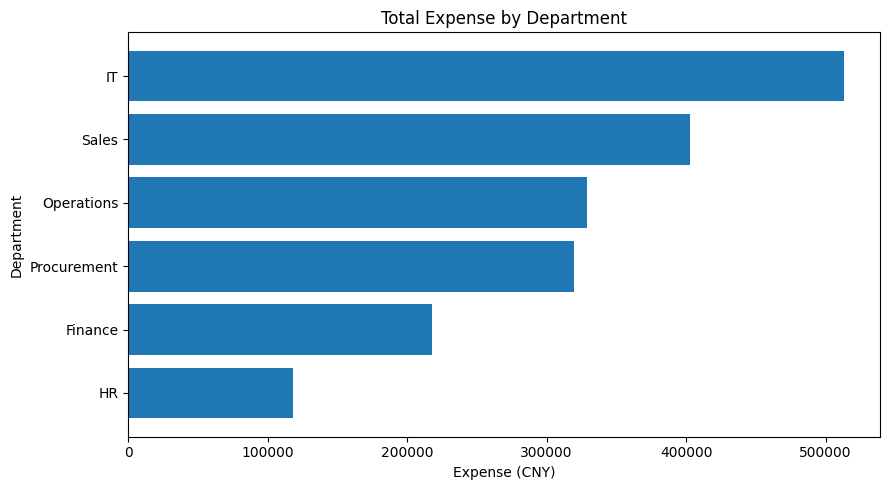

In [5]:
plt.figure(figsize=(9, 5))
plot_data = dept_spend.sort_values("Total_CNY")
plt.barh(plot_data["Department"], plot_data["Total_CNY"])
plt.title("Total Expense by Department")
plt.xlabel("Expense (CNY)")
plt.ylabel("Department")
plt.tight_layout()
plt.show()


## 3. Rule-based anomaly detection

The purpose of these flags is **not** to label transactions as fraud. They identify transactions or patterns that may warrant further review.

The thresholds below are deliberately transparent so that each flag can be explained and challenged by a reviewer.


### 3.1 High-value transactions

In [6]:
# Category-specific rule: flag transactions above the 97th percentile within each expense category.
category_thresholds = df.groupby("Expense_Category")["Amount_CNY"].quantile(0.97)

df["High_Value_Flag"] = df.apply(
    lambda r: r["Amount_CNY"] > category_thresholds.loc[r["Expense_Category"]],
    axis=1
)

high_value = df[df["High_Value_Flag"]].copy().sort_values("Amount_CNY", ascending=False)

print(f"High-value flags: {len(high_value)}")
high_value[[
    "Transaction_ID", "Date", "Department", "Expense_Category",
    "Vendor", "Amount_CNY", "Description"
]].head(15)


High-value flags: 28


,Transaction_ID,Date,Department,Expense_Category,Vendor,Amount_CNY,Description
838,TXN-0371,2026-06-05,Procurement,Software & IT,CloudSuite,32056,IT equipment/accessory - exceptional amount
846,TXN-0950,2026-06-05,Procurement,Software & IT,CloudSuite,32056,IT equipment/accessory - exceptional amount
132,TXN-0764,2026-01-28,Finance,Software & IT,CloudSuite,30438,Software subscription - exceptional amount
457,TXN-0840,2026-03-31,IT,Software & IT,DataWorks,30229,Cloud service fee - exceptional amount
4,TXN-0256,2026-01-01,Sales,Training,SkillLab,20263,Employee development - exceptional amount
638,TXN-0545,2026-05-04,IT,Travel,Metro Hotel,18731,Project travel expense - exceptional amount
967,TXN-0805,2026-06-24,IT,Office Supplies,Stationery Hub,16445,General office supplies - exceptional amount
507,TXN-0073,2026-04-09,Sales,Office Supplies,Stationery Hub,14934,Office consumables - exceptional amount
534,TXN-0262,2026-04-14,IT,Office Supplies,WorkBasics,14728,Printing and stationery - exceptional amount
869,TXN-0604,2026-06-10,IT,Software & IT,CloudSuite,14600,Software / IT service purchase


### 3.2 Duplicate-like transactions

In [7]:
duplicate_keys = [
    "Date", "Employee_ID", "Expense_Category",
    "Vendor", "Amount_CNY"
]

df["Duplicate_Flag"] = df.duplicated(subset=duplicate_keys, keep=False)

duplicates = (
    df[df["Duplicate_Flag"]]
    .sort_values(duplicate_keys)
    .copy()
)

print(f"Transactions in duplicate-like groups: {len(duplicates)}")
duplicates[[
    "Transaction_ID", "Date", "Employee_ID", "Department",
    "Expense_Category", "Vendor", "Amount_CNY"
]].head(20)


Transactions in duplicate-like groups: 28


,Transaction_ID,Date,Employee_ID,Department,Expense_Category,Vendor,Amount_CNY
94,TXN-0234,2026-01-22,E018,Operations,Transportation,RailLink,140
100,TXN-0970,2026-01-22,E018,Operations,Transportation,RailLink,140
167,TXN-0473,2026-02-04,E022,IT,Software & IT,CloudSuite,1310
171,TXN-0890,2026-02-04,E022,IT,Software & IT,CloudSuite,1310
237,TXN-0621,2026-02-17,E033,Procurement,Meals,Green Table,330
240,TXN-0997,2026-02-17,E033,Procurement,Meals,Green Table,330
301,TXN-0210,2026-03-02,E022,IT,Training,ProLearning,550
308,TXN-0990,2026-03-02,E022,IT,Training,ProLearning,550
331,TXN-0536,2026-03-06,E009,Sales,Software & IT,SoftLink,1910
333,TXN-0954,2026-03-06,E009,Sales,Software & IT,SoftLink,1910


### 3.3 Weekend transactions

In [8]:
df["Weekend_Flag"] = df["Date"].dt.dayofweek >= 5

weekend_txns = df[df["Weekend_Flag"]].copy()

print(f"Weekend transactions: {len(weekend_txns)}")
weekend_txns[[
    "Transaction_ID", "Date", "Employee_ID", "Department",
    "Expense_Category", "Vendor", "Amount_CNY"
]].head(15)


Weekend transactions: 22


,Transaction_ID,Date,Employee_ID,Department,Expense_Category,Vendor,Amount_CNY
44,TXN-0645,2026-01-11,E014,Sales,Software & IT,CloudSuite,620
45,TXN-0757,2026-01-11,E017,Operations,Professional Services,ConsultPro,3980
109,TXN-0125,2026-01-25,E021,Operations,Meals,Green Table,560
146,TXN-0457,2026-02-01,E016,Operations,Travel,Harbor Hotel,2060
187,TXN-0135,2026-02-07,E001,Finance,Training,SkillLab,1280
227,TXN-0216,2026-02-15,E011,Sales,Meals,Coffee Point,110
262,TXN-0356,2026-02-21,E002,Finance,Professional Services,AdvisoryOne,5020
370,TXN-0500,2026-03-14,E026,IT,Meals,LunchBox,190
443,TXN-0797,2026-03-29,E016,Operations,Software & IT,SoftLink,1970
559,TXN-0859,2026-04-19,E001,Finance,Software & IT,SoftLink,1330


### 3.4 High-frequency reimbursements

In [9]:
daily_employee_counts = (
    df.groupby(["Employee_ID", "Date"])
      .size()
      .reset_index(name="Transactions_Per_Day")
)

high_frequency_days = daily_employee_counts[
    daily_employee_counts["Transactions_Per_Day"] >= 5
].copy()

high_frequency = df.merge(
    high_frequency_days,
    on=["Employee_ID", "Date"],
    how="inner"
).sort_values(["Transactions_Per_Day", "Employee_ID", "Date"], ascending=[False, True, True])

print(f"Employee-days with 5+ transactions: {len(high_frequency_days)}")
high_frequency_days.sort_values("Transactions_Per_Day", ascending=False).head(10)


Employee-days with 5+ transactions: 1


,Employee_ID,Date,Transactions_Per_Day
224,E010,2026-05-15,8


### 3.5 Vendor concentration

In [10]:
vendor_spend = (
    df.groupby("Vendor", as_index=False)["Amount_CNY"]
      .agg(["count", "sum"])
      .reset_index()
      .rename(columns={"count": "Transactions", "sum": "Total_CNY"})
      .sort_values("Total_CNY", ascending=False)
)

vendor_spend["Share_of_Total"] = vendor_spend["Total_CNY"] / df["Amount_CNY"].sum()

vendor_spend.head(10)


,index,Vendor,Transactions,Total_CNY,Share_of_Total
5,5,CloudSuite,38,273270,0.14
30,30,TravelHub,39,138890,0.07
4,4,CityStay,39,137040,0.07
26,26,Skyline Hotel,38,129600,0.07
16,16,Metro Hotel,38,122551,0.06
29,29,TechSource,43,114180,0.06
12,12,Harbor Hotel,34,103620,0.05
8,8,DataWorks,20,79719,0.04
7,7,ConsultPro,16,77680,0.04
19,19,OfficeMart,58,68130,0.04


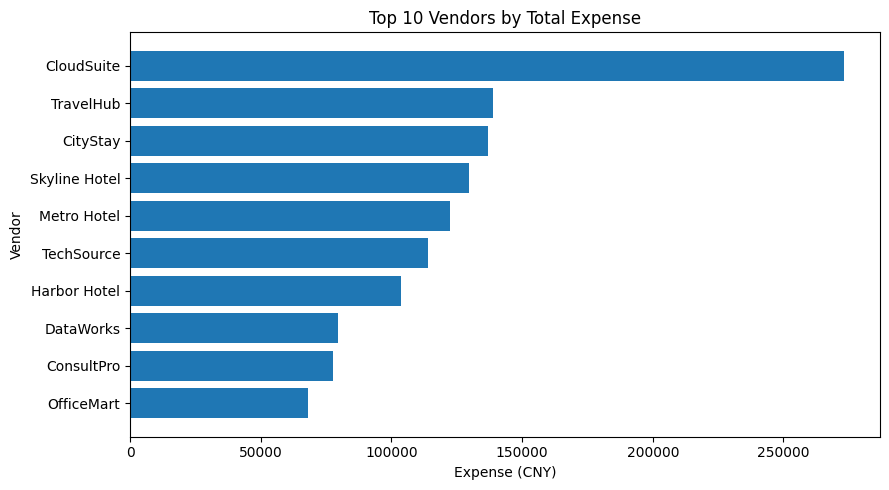

In [11]:
plt.figure(figsize=(9, 5))
top_vendors = vendor_spend.head(10).sort_values("Total_CNY")
plt.barh(top_vendors["Vendor"], top_vendors["Total_CNY"])
plt.title("Top 10 Vendors by Total Expense")
plt.xlabel("Expense (CNY)")
plt.ylabel("Vendor")
plt.tight_layout()
plt.show()


### 3.6 Department-level monthly spending spikes

In [12]:
df["Month"] = df["Date"].dt.to_period("M").astype(str)

monthly_dept = (
    df.groupby(["Department", "Month"], as_index=False)["Amount_CNY"]
      .sum()
      .rename(columns={"Amount_CNY": "Monthly_Expense_CNY"})
)

monthly_dept["Dept_Mean"] = monthly_dept.groupby("Department")["Monthly_Expense_CNY"].transform("mean")
monthly_dept["Dept_Std"] = monthly_dept.groupby("Department")["Monthly_Expense_CNY"].transform("std")

monthly_dept["Z_Score"] = (
    (monthly_dept["Monthly_Expense_CNY"] - monthly_dept["Dept_Mean"]) /
    monthly_dept["Dept_Std"].replace(0, np.nan)
)

monthly_dept["Spending_Spike_Flag"] = monthly_dept["Z_Score"] > 1.5

monthly_dept.sort_values(["Spending_Spike_Flag", "Z_Score"], ascending=[False, False]).head(15)


,Department,Month,Monthly_Expense_CNY,Dept_Mean,Dept_Std,Z_Score,Spending_Spike_Flag
17,IT,2026-06,274615,"85,548.17","93,852.86",2.01,True
29,Procurement,2026-06,104252,"53,320.67","26,745.02",1.90,True
0,Finance,2026-01,65328,"36,284.67","18,613.18",1.56,True
19,Operations,2026-02,78600,"54,860.50","17,531.74",1.35,False
10,HR,2026-05,28800,"19,731.67","7,348.86",1.23,False
35,Sales,2026-06,88379,"67,157.17","19,691.44",1.08,False
21,Operations,2026-04,72390,"54,860.50","17,531.74",1.00,False
9,HR,2026-04,26370,"19,731.67","7,348.86",0.90,False
1,Finance,2026-02,53090,"36,284.67","18,613.18",0.90,False
32,Sales,2026-03,82400,"67,157.17","19,691.44",0.77,False


## 4. Combined review score

In [13]:
# Add a transparent review score based on transaction-level flags.
# A higher score means more reasons to review, not a stronger allegation of wrongdoing.

# High-frequency indicator at transaction level
hf_keys = set(zip(high_frequency["Employee_ID"], high_frequency["Date"]))
df["High_Frequency_Flag"] = [
    (emp, date) in hf_keys for emp, date in zip(df["Employee_ID"], df["Date"])
]

df["Review_Score"] = (
    df["High_Value_Flag"].astype(int) * 2 +
    df["Duplicate_Flag"].astype(int) * 2 +
    df["Weekend_Flag"].astype(int) +
    df["High_Frequency_Flag"].astype(int)
)

review_queue = (
    df[df["Review_Score"] > 0]
    .sort_values(["Review_Score", "Amount_CNY"], ascending=[False, False])
    .copy()
)

print(f"Transactions flagged for at least one review reason: {len(review_queue)}")
review_queue[[
    "Transaction_ID", "Date", "Employee_ID", "Department",
    "Expense_Category", "Vendor", "Amount_CNY",
    "High_Value_Flag", "Duplicate_Flag",
    "Weekend_Flag", "High_Frequency_Flag", "Review_Score"
]].head(20)


Transactions flagged for at least one review reason: 78


,Transaction_ID,Date,Employee_ID,Department,Expense_Category,Vendor,Amount_CNY,High_Value_Flag,Duplicate_Flag,Weekend_Flag,High_Frequency_Flag,Review_Score
838,TXN-0371,2026-06-05,E032,Procurement,Software & IT,CloudSuite,32056,True,True,False,False,4
846,TXN-0950,2026-06-05,E032,Procurement,Software & IT,CloudSuite,32056,True,True,False,False,4
974,TXN-0403,2026-06-25,E007,Sales,Professional Services,ConsultPro,12000,True,True,False,False,4
980,TXN-0965,2026-06-25,E007,Sales,Professional Services,ConsultPro,12000,True,True,False,False,4
720,TXN-0825,2026-05-15,E010,Sales,Meals,Golden Bowl,320,False,True,False,True,3
722,TXN-0827,2026-05-15,E010,Sales,Meals,Golden Bowl,320,False,True,False,True,3
718,TXN-0823,2026-05-15,E010,Sales,Meals,LunchBox,280,False,True,False,True,3
723,TXN-0828,2026-05-15,E010,Sales,Meals,LunchBox,280,False,True,False,True,3
132,TXN-0764,2026-01-28,E005,Finance,Software & IT,CloudSuite,30438,True,False,False,False,2
457,TXN-0840,2026-03-31,E022,IT,Software & IT,DataWorks,30229,True,False,False,False,2


## 5. Review summary

In [14]:
review_summary = pd.DataFrame({
    "Review Area": [
        "High-value transactions",
        "Transactions in duplicate-like groups",
        "Weekend transactions",
        "High-frequency employee-days",
        "Transactions with at least one review flag"
    ],
    "Count": [
        int(df["High_Value_Flag"].sum()),
        int(df["Duplicate_Flag"].sum()),
        int(df["Weekend_Flag"].sum()),
        len(high_frequency_days),
        len(review_queue)
    ]
})

review_summary


,Review Area,Count
0,High-value transactions,28
1,Transactions in duplicate-like groups,28
2,Weekend transactions,22
3,High-frequency employee-days,1
4,Transactions with at least one review flag,78


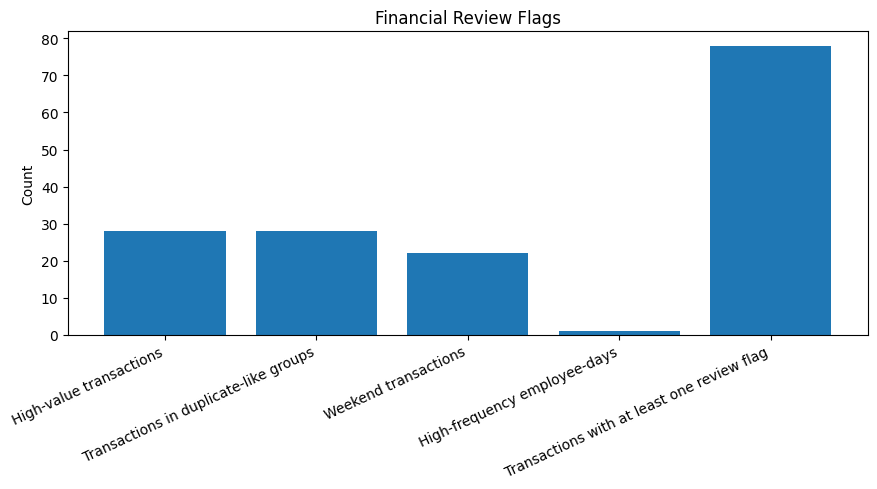

In [15]:
plt.figure(figsize=(9, 5))
plt.bar(review_summary["Review Area"], review_summary["Count"])
plt.title("Financial Review Flags")
plt.ylabel("Count")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()


## 6. AI-assisted interpretation and human validation

Generative AI can help structure review questions and summarise patterns, but the model should **not** make the final accounting, compliance or fraud judgement.

A practical human-AI workflow for this project is:

1. **Human:** define business context and financial review objectives.
2. **Python:** apply transparent analytical rules and generate reproducible flags.
3. **AI:** help summarise patterns, suggest follow-up questions and explain code.
4. **Human:** trace flagged items back to source data and assess economic substance.
5. **Human:** determine whether an item is reasonable, requires additional evidence, or should be escalated.

### Example follow-up questions for flagged items

- Is there a valid business reason for the unusually high amount?
- Does the transaction have complete supporting documentation?
- Are duplicate-like entries separate legitimate expenses or duplicate claims?
- Are weekend transactions consistent with travel or operational requirements?
- Does repeated spending with one vendor reflect a contract, procurement arrangement or concentration risk?
- Is a departmental spending spike linked to a planned project, renewal or one-off investment?

This approach treats AI as a productivity and reasoning aid while retaining professional judgement, data traceability and human accountability.


## 7. Key takeaway

This demonstration shows how a finance professional can combine:

- financial domain knowledge,
- structured data analysis,
- transparent anomaly-detection rules,
- AI-assisted reasoning, and
- human validation

to improve the efficiency and consistency of financial review.

The goal is not to automate professional judgement, but to use AI and analytics to focus human attention on transactions and patterns that deserve further investigation.
